In [1]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.interpolate import RegularGridInterpolator
from multiprocessing import Pool
import os
import time
import emcee
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# ====================================================
# Loading CC data
# ====================================================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

z_cc  = df_cc["z_cc"].to_numpy(float)
H_obs = df_cc["H_cc"].to_numpy(float)
H_err = df_cc["H_cc_err"].to_numpy(float)


# ====================================================
# Loading SNe Ia data (Pantheon+SH0ES)
# ====================================================

sne_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES.dat"
sne_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES_STAT+SYS.cov"

df_sne       = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")
raw_cov      = np.loadtxt(sne_cov_path, skiprows=1)
Cov_sne_full = raw_cov.reshape((1701, 1701))

mask     = df_sne["zCMB"].values > 0.01
df_cut   = df_sne[mask].reset_index(drop=True)
Cov_sne  = Cov_sne_full[mask, :][:, mask]
z_sne    = df_cut["zCMB"].values
mB_obs   = df_cut["m_b_corr"].values

Cinv_sne = np.linalg.inv(Cov_sne)


# ========================================================
# Loading DESI BAO DR2 data
# ========================================================

bao_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_cov.txt"

df_bao   = pd.read_csv(bao_dat_path, sep=r"\s+", comment="#", names=["z", "value", "quantity"])

z_bao    = df_bao["z"].values
d_obs    = df_bao["value"].values
q_bao    = df_bao["quantity"].str.lower().values

cov_bao  = np.loadtxt(bao_cov_path)
Cinv_bao = np.linalg.inv(cov_bao)

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Uniform priors
H0_min,       H0_max       = 50.0,   90.0
Om0_min,      Om0_max      = 0.1,    0.6
MB_min,       MB_max       = -19.8,  -18.6
b_min,        b_max        = 1.6,    12.0

# Gaussian priors
mu_Ob, sigma_Ob = 0.0495, 0.0025
mu_MB, sigma_MB = -19.24, 0.04

# Physical constants
c_kms = 299792.458         # speed of light [km/s]
c_si  = 2.99792458e8       # speed of light [m/s]
G_si  = 6.67430e-11        # gravitational constant [m^3 kg^-1 s^-2]
mp_si = 1.67262192369e-27  # proton mass [kg]

# Astrophysical/cosmological parameters
Neff  = 3.046

# Scalaron mass scale
delta_s = 1e-7


# ====================================================
# Redshift / scale-factor grids
# ====================================================

ai, af = 0.2, 1.0
zi, zf = 0.0, 4.0
N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)
dz     = np.diff(z_grid)

In [4]:
# ====================================================
# Curvature scale (ε) in AB f(R) gravity
# ====================================================

def compute_epsilon(H0, b):
    R_vac = 12.0 * H0**2
    L = np.log1p(np.exp(2.0 * b)) if b < 20.0 else 2.0 * b + np.exp(-2.0 * b)
    return R_vac / L


# ====================================================
# Custom exception for ODE failure
# ====================================================

class ODEFailure(Exception):
    pass


# ====================================================
# ODE system for H(a) in AB f(R) gravity
# ====================================================

def Hubble_AB_a(a, y, H0, Om0, b, epsilon, M2):
    """
    ODE system for H(a) in the AB f(R) model.
    epsilon and M2 are pre-computed outside the integrator.
    """
    
    H, dH, ddH = y

    Om    = Om0 * a**(-3)
    R     = 6.0 * H * (2.0 * H + a * dH)
    alpha = (R / epsilon) - b

    abs_a = abs(alpha)
    if abs_a < 20.0:
        tanh_a = np.tanh(alpha)
        sech_a = 1.0 / np.cosh(alpha)
    else:
        tanh_a = 1.0 if alpha > 0 else -1.0
        sech_a = 2.0 * np.exp(-abs_a)

    A = H0**2 * (3.0 * Om)
    B = a * H * dH * (tanh_a + 1.0)
    C = 4.0 * a * H**2 * dH * (a * dH + 2.0 * H) / M2
    D = ((6.0 * a**2 * H**2 / epsilon)**2
         * ((5.0 * dH / a) + (dH**2 / H) + ddH)**2
         * tanh_a * (sech_a**2))
    E = 6.0 * a**3 * H**3 * (1.0 / (3.0 * M2) + 0.5 * (sech_a**2) / epsilon)

    if E == 0 or not np.isfinite(E):
        raise ODEFailure(f"E singular or non-finite at a={a:.4f}")

    F = ((11.0 * dH**2) / (a * H) + (dH**3) / (H**2)
         + (6.0 * ddH / a) + (4.0 * dH * ddH / H))

    dddH = -(A + B + C - D) / E - F
    return [dH, ddH, dddH]

In [5]:
# ====================================================
# ODE integration → H(a)
# ====================================================

def H_AB_a(a_eval, H0, Om0, b):
    """
    Integrates the AB f(R) ODE system using DOP853.
    epsilon and M2 are pre-computed once and passed
    to the ODE to avoid per-step overhead.
    """
    
    epsilon = compute_epsilon(H0, b)
    M2      = epsilon / delta_s

    Omi  = Om0 * ai**(-3)
    Ol0  = 1.0 - Om0
    Hi   = H0 * np.sqrt(Omi + Ol0)
    dHi  = -(H0**2) / (2.0 * ai * Hi) * (3.0 * Omi)
    ddHi = (0.5 * (H0 / (ai * Hi))**2 * (Hi + ai * dHi) * (3.0 * Omi)
            + 0.5 * (H0 / (ai * Hi))**2 * Hi * (9.0 * Omi))

    y0 = [Hi, dHi, ddHi]

    try:
        sol = solve_ivp(
            Hubble_AB_a,
            (ai, af),
            y0,
            t_eval=a_eval,
            method="DOP853",
            rtol=1e-5,
            atol=1e-8,
            args=(H0, Om0, b, epsilon, M2),
            dense_output=False
        )
    except ODEFailure:
        return None

    if sol.status < 0 or np.any(~np.isfinite(sol.y)):
        return None

    return sol.y[0]


# ====================================================
# H(z) via a = 1/(1+z) conversion
# ====================================================

def H_AB_z(z_eval, H0, Om0, b):
    """
    Converts z → a, integrates H(a) over [ai, af], and
    returns H(z) in the original ordering of z_eval.
    Points outside the integration domain receive NaN.
    Duplicate a-values are removed before integration
    to avoid instabilities in solve_ivp.
    """

    z_eval = np.atleast_1d(np.asarray(z_eval, dtype=float))
    a_eval = 1.0 / (1.0 + z_eval)

    in_domain = (a_eval >= ai) & (a_eval <= af)
    if not np.any(in_domain):
        return None

    valid_idx = np.where(in_domain)[0]
    a_valid   = a_eval[valid_idx]

    sort_idx    = np.argsort(a_valid)
    a_sorted    = a_valid[sort_idx]
    unique_mask = np.concatenate(([True], np.diff(a_sorted) > 1e-12))
    a_unique    = a_sorted[unique_mask]

    H_unique = H_AB_a(a_unique, H0, Om0, b)
    if H_unique is None:
        return None

    if not np.all(unique_mask):
        H_at_sorted = np.interp(a_sorted, a_unique, H_unique)
    else:
        H_at_sorted = H_unique

    H_valid           = np.empty(len(a_valid))
    H_valid[sort_idx] = H_at_sorted

    H_z            = np.full(len(z_eval), np.nan)
    H_z[valid_idx] = H_valid

    return H_z

In [6]:
# ====================================================
# Worker function (module level — required for pickle)
# ====================================================

def _grid_worker(args):
    """
    Computes H(z) for a single (H0, Om0, b) grid point.
    Returns (i, j, k, H_values) or (i, j, k, None) on failure.
    """

    i, j, k, H0, Om0, b, z_pts = args
    Hvals = H_AB_z(z_pts, H0, Om0, b)
    if Hvals is not None and np.all(np.isfinite(Hvals)):
        return (i, j, k, Hvals)
    else:
        return (i, j, k, None)


# ====================================================
# Parallel grid builder
# ====================================================

def build_H_grid_parallel(H0_pts, Om0_pts, b_pts, z_pts,
                           n_cores=None, verbose=True):
    """
    Builds the 4D array H[i_H0, i_Om0, i_b, i_z] in parallel
    using multiprocessing.Pool.
    """

    nH  = len(H0_pts)
    nOm = len(Om0_pts)
    nb  = len(b_pts)
    nz  = len(z_pts)

    total   = nH * nOm * nb
    n_cores = n_cores or os.cpu_count()

    tasks = [
        (i, j, k, H0, Om0, b, z_pts)
        for i, H0  in enumerate(H0_pts)
        for j, Om0 in enumerate(Om0_pts)
        for k, b   in enumerate(b_pts)
    ]

    H_array   = np.full((nH, nOm, nb, nz), np.nan)
    nan_count = 0

    if verbose:
        print(f"  Total grid points : {total} ({nH}×{nOm}×{nb})")
        print(f"  Workers           : {n_cores}")
        print(f"  {'PCT':>5}  {'Done':>8}  {'Elapsed':>9}  {'ETA':>9}  {'Rate':>12}")
        print("  " + "-"*55)

    t0       = time.time()
    count    = 0
    last_pct = -1
    chunksize = max(1, total // (n_cores * 20))

    with Pool(processes=n_cores) as pool:
        for result in pool.imap_unordered(_grid_worker, tasks,
                                           chunksize=chunksize):
            i, j, k, Hvals = result
            if Hvals is not None:
                H_array[i, j, k, :] = Hvals
            else:
                nan_count += 1

            count   += 1
            elapsed  = time.time() - t0
            pct      = int(count / total * 100)

            if verbose and (pct >= last_pct + 10 or count == total):
                eta  = (elapsed / count) * (total - count) if count < total else 0.0
                rate = count / elapsed if elapsed > 0 else 0.0
                print(f"  {pct:>4}%  {count:>8}/{total}  "
                      f"{elapsed:>7.1f}s  "
                      f"ETA {eta:>6.1f}s  "
                      f"{rate:>8.1f} pts/s")
                last_pct = pct

    nan_frac = nan_count / total
    if nan_frac > 0:
        print(f"\n  ⚠  {100*nan_frac:.1f}% NaN in grid — "
              f"check prior bounds or ODE stability.")
    else:
        print(f"\n  ✓  Grid complete with no NaN points.")

    total_time = time.time() - t0
    print(f"  Total time: {total_time:.1f}s ({total_time/60:.2f} min)")

    return H_array


# ====================================================
# Interpolation error validation
# ====================================================

def validate_interpolation_error(H_interp_4D, H0_pts, Om0_pts, b_pts, z_pts,
                                  n_test=300, tol_percent=0.5):
    """
    Validates the interpolator against direct ODE solutions at
    n_test random interior points.
    """

    rng_v  = np.random.default_rng(0)
    errors = []

    for _ in range(n_test):
        H0_t  = rng_v.uniform(H0_pts[1],  H0_pts[-2])
        Om0_t = rng_v.uniform(Om0_pts[1], Om0_pts[-2])
        b_t   = rng_v.uniform(b_pts[1],   b_pts[-2])

        H_true = H_AB_z(z_pts, H0_t, Om0_t, b_t)
        if H_true is None or not np.all(np.isfinite(H_true)):
            continue

        pts      = np.column_stack([np.full(len(z_pts), H0_t),
                                    np.full(len(z_pts), Om0_t),
                                    np.full(len(z_pts), b_t),
                                    z_pts])
        H_interp = H_interp_4D(pts)
        rel_err  = np.abs((H_true - H_interp) / H_true) * 100.0
        errors.append(np.max(rel_err))

    errors = np.array(errors)

    print(f"\n  Interpolation validation ({n_test} random interior points):")
    print(f"  Max error    : {errors.max():.4f}%")
    print(f"  Median error : {np.median(errors):.4f}%")
    print(f"  95th pct     : {np.percentile(errors, 95):.4f}%")

    if errors.max() < tol_percent:
        print(f"  ✓  Interpolator approved (max error < {tol_percent}%). "
              f"Ready for MCMC.")
    else:
        print(f"  ✗  Max error exceeds {tol_percent}%! "
              f"Increase grid resolution (n_H0, n_Om0, n_b).")

    return errors


# ====================================================
# 4D interpolation grid parameters
# ====================================================

n_H0  = 30
n_Om0 = 30
n_b   = 30

H0_grid_pts  = np.linspace(H0_min,  H0_max,  n_H0)
Om0_grid_pts = np.linspace(Om0_min, Om0_max, n_Om0)
b_grid_pts   = np.linspace(b_min,   b_max,   n_b)


# ====================================================
# Build grid (parallel)
# ====================================================

print("\n=== Building 4D interpolation grid (parallel) ===")
H_array = build_H_grid_parallel(
    H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid,
    n_cores=112
)


# ====================================================
# Build interpolator
# ====================================================

H_interp_4D = RegularGridInterpolator(
    (H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid),
    H_array,
    method="linear",
    bounds_error=False,
    fill_value=np.nan       # explicit NaN outside grid bounds
)


# ====================================================
# Validate interpolator
# ====================================================

print("\n=== Validating interpolator ===")
errors = validate_interpolation_error(
    H_interp_4D, H0_grid_pts, Om0_grid_pts, b_grid_pts, z_grid
)


=== Building 4D interpolation grid (parallel) ===
  Total grid points : 27000 (30×30×30)
  Workers           : 112
    PCT      Done    Elapsed        ETA          Rate
  -------------------------------------------------------
     9%      2430/27000      7.3s  ETA   74.1s     331.7 pts/s
    19%      5130/27000     13.7s  ETA   58.4s     374.3 pts/s
    29%      7831/27000     20.0s  ETA   48.9s     392.2 pts/s
    39%     10530/27000     26.3s  ETA   41.1s     401.0 pts/s
    49%     13230/27000     32.5s  ETA   33.8s     407.0 pts/s
    59%     15930/27000     38.8s  ETA   27.0s     410.0 pts/s
    69%     18630/27000     45.2s  ETA   20.3s     412.1 pts/s
    79%     21330/27000     51.9s  ETA   13.8s     410.8 pts/s
    89%     24030/27000     58.7s  ETA    7.2s     409.7 pts/s
    99%     26730/27000     64.3s  ETA    0.6s     415.8 pts/s
   100%     27000/27000     64.6s  ETA    0.0s     417.9 pts/s

  ✓  Grid complete with no NaN points.
  Total time: 64.7s (1.08 min)

=== Val

In [7]:
# ================================================================
# Hubble function (interpolated) — used inside MCMC likelihood
# ================================================================

def H_AB_interp(z_eval, H0, Om0, b):
    pts = np.column_stack([
        np.full(len(z_eval), H0),
        np.full(len(z_eval), Om0),
        np.full(len(z_eval), b),
        z_eval
    ])
    return H_interp_4D(pts)


# ================================================================
# Apparent magnitude (interpolated) — used inside MCMC likelihood
# ================================================================

def dL_AB_interp(z, H0, Om0, b):
    H_interp   = H_AB_interp(z_grid, H0, Om0, b)
    prefactor  = c_kms * (1.0 + z)
    integrand  = 1.0 / H_interp
    integral   = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    integral_z = np.interp(z, z_grid, integral)
    return prefactor * integral_z

def mB_AB_interp(z, H0, Om0, MB, b):
    dL_interp = dL_AB_interp(z, H0, Om0, b)
    mu = 5.0 * np.log10(dL_interp) + 25.0
    return mu + MB


# ================================================================
# BAO observables (interpolated) — used inside MCMC likelihood
# ================================================================

def comoving_dist_interp(z, H0, Om0, b):
    H_interp  = H_AB_interp(z_grid, H0, Om0, b)
    integrand = 1.0 / H_interp
    integral     = np.empty_like(z_grid)
    integral[0]  = 0.0
    integral[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
    I_z = np.interp(z, z_grid, integral)
    return c_kms * I_z

def d_bao_AB_interp(z_arr, q_arr, H0, Om0, Ob, b):
    h2   = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd   = 147.05 * ((Obh2 / 0.02236)**-0.13) \
                  * ((Omh2 / 0.1432)**-0.23) \
                  * ((Neff / 3.04)**-0.1)
    dC  = comoving_dist_interp(z_arr, H0, Om0, b)
    H_z = H_AB_interp(z_arr, H0, Om0, b)
    dm = dC / rd
    dh = (c_kms / H_z) / rd
    dv = (z_arr * dm**2 * dh)**(1.0 / 3.0)
    d_bao          = np.empty_like(z_arr)
    mask_dv        = np.array(["dv" in q for q in q_arr])
    mask_dm        = np.array(["dm" in q for q in q_arr])
    mask_dh        = np.array(["dh" in q for q in q_arr])
    d_bao[mask_dv] = dv[mask_dv]
    d_bao[mask_dm] = dm[mask_dm]
    d_bao[mask_dh] = dh[mask_dh]
    return d_bao

In [8]:
# ====================================================
# CC + SNe + BAO likelihood
# ====================================================

# Toggle: Choose a prior for b
USE_LOG_b_PRIOR = False   # True = Jeffreys (log b) | False = Uniform (b)

# Bounds
if USE_LOG_b_PRIOR:
    b_param_min = np.log(b_min)
    b_param_max = np.log(50.0)
else:
    b_param_min = b_min
    b_param_max = b_max


# Log-prior
def lnprior_cc_sne_bao(theta):
    H0, Om0, Ob, MB, b_param = theta
    if not (H0_min       <= H0         <= H0_max):       return -np.inf
    if not (Om0_min      <= Om0        <= Om0_max):      return -np.inf
    if not (0.0          <  Ob         <  Om0):          return -np.inf
    if not (MB_min       <= MB         <= MB_max):       return -np.inf
    if not (b_param_min  <= b_param    <= b_param_max):  return -np.inf
    lp_Ob = -0.5 * ((Ob - mu_Ob) / sigma_Ob)**2
    lp_MB = -0.5 * ((MB - mu_MB) / sigma_MB)**2
    return lp_Ob + lp_MB


# Joint likelihood
def lnlike_cc_sne_bao(theta,
                      z_cc, H_obs, H_err,
                      z_sne, mB_obs, Cinv_sne,
                      z_bao, d_obs, q_bao, Cinv_bao):
    H0, Om0, Ob, MB, b_param = theta
    b = np.exp(b_param) if USE_LOG_b_PRIOR else b_param
    # --- CC ---
    H_model = H_AB_interp(z_cc, H0, Om0, b)
    if not np.all(np.isfinite(H_model)):
        return -np.inf
    lnL_cc = -0.5 * np.sum(((H_obs - H_model) / H_err)**2)
    # --- SNe ---
    mB_model = mB_AB_interp(z_sne, H0, Om0, MB, b)
    if not np.all(np.isfinite(mB_model)):
        return -np.inf
    resid_sne = mB_obs - mB_model
    lnL_sne   = -0.5 * (resid_sne @ Cinv_sne @ resid_sne)
    # --- BAO ---
    d_model = d_bao_AB_interp(z_bao, q_bao, H0, Om0, Ob, b)
    if not np.all(np.isfinite(d_model)):
        return -np.inf
    resid_bao = d_obs - d_model
    lnL_bao   = -0.5 * (resid_bao @ Cinv_bao @ resid_bao)
    return lnL_cc + lnL_sne + lnL_bao


# Joint posterior
def lnprob_cc_sne_bao(theta,
                      z_cc, H_obs, H_err,
                      z_sne, mB_obs, Cinv_sne,
                      z_bao, d_obs, q_bao, Cinv_bao):
    lp = lnprior_cc_sne_bao(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_cc_sne_bao(theta,
                                   z_cc, H_obs, H_err,
                                   z_sne, mB_obs, Cinv_sne,
                                   z_bao, d_obs, q_bao, Cinv_bao)


# ====================================================
# Quick test
# ====================================================

b_test     = np.log(2.5) if USE_LOG_b_PRIOR else 2.5
theta_test = [70.0, 0.3, 0.0495, -19.24, b_test]
print(f"Prior type : {'Jeffreys (log b)' if USE_LOG_b_PRIOR else 'Uniform (b)'}")
print("CC + SNe + BAO log-posterior =",
                      lnprob_cc_sne_bao(theta_test,
                                        z_cc, H_obs, H_err,
                                        z_sne, mB_obs, Cinv_sne,
                                        z_bao, d_obs, q_bao, Cinv_bao))

Prior type : Uniform (b)
CC + SNe + BAO log-posterior = -816.0816955787409


In [9]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 5
nwalkers = 40
nsteps   = 50000

b_init = np.log(2.5) if USE_LOG_b_PRIOR else 2.5
bscale = 0.3         if USE_LOG_b_PRIOR else 0.1

theta0 = np.array([70.0, 0.3, 0.0495, -19.24, b_init])
scales = np.array([ 2.0, 0.02, 0.001,   0.02, bscale])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))
for i in range(nwalkers):
    while not np.isfinite(lnprior_cc_sne_bao(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)

# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (CC + SNe + BAO | {'Jeffreys' if USE_LOG_b_PRIOR else 'Uniform'} prior) ===")

t_mcmc = time.time()
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_cc_sne_bao,
    args=(z_cc, H_obs, H_err, z_sne, mB_obs, Cinv_sne,
          z_bao, d_obs, q_bao, Cinv_bao)
)
sampler.run_mcmc(p0, nsteps, progress=True)

print(f"\nMCMC completed in {(time.time() - t_mcmc) / 60:.1f} min")


=== Running MCMC (CC + SNe + BAO | Uniform prior) ===


100%|██████████| 50000/50000 [38:24<00:00, 21.69it/s]


MCMC completed in 38.4 min


In [10]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")

chain        = sampler.get_chain()
nsteps_total = chain.shape[0]
acc_frac = np.mean(sampler.acceptance_fraction)

print(f"Mean acceptance fraction: {acc_frac:.3f}")

if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"

print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max

print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")

length_status = "PASSED" if length_ratio >= 50 else "FAILED"

print(f"Length criterion (>50×τ)       : {length_status}")

nburn     = int(3 * tau_max)
nthin     = max(1, int(tau_max / 2))
n_post    = nsteps_total - nburn
N_eff     = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)

print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")

if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"

print(f"Sampling quality               : {eff_status}")
if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.469
Acceptance status: IDEAL

Max autocorrelation time τ_max = 520.20
Chain length / τ_max           = 96.1
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 1560 steps (3.1%)
Thin (τ_max/2)                 = 260
Minimum N_eff                  = 3724
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [11]:
# ====================================================
# Chain extraction — converter log_b → b if needed
# ====================================================

# flat_log     = sampler.get_chain(discard=nburn, thin=nthin, flat=True)      # Apply thin
flat_log     = sampler.get_chain(discard=nburn, flat=True)                    # No thin
flat_samples = flat_log.copy()
if USE_LOG_b_PRIOR:
    flat_samples[:, 4] = np.exp(flat_log[:, 4])

fname = "flat_samples_AB_cc_sne_bao_jeff.npy" if USE_LOG_b_PRIOR else "flat_samples_AB_cc_sne_bao.npy"
np.save(fname, flat_samples)

print(f"\nFinal independent samples : {len(flat_samples)}")
print(f"Burn-in used              : {nburn} steps")
# print(f"Thin                      : {nthin}")
print(f"Saved to                  : {fname}")


Final independent samples : 1937600
Burn-in used              : 1560 steps
Saved to                  : flat_samples_AB_cc_sne_bao.npy


Removed no burn in


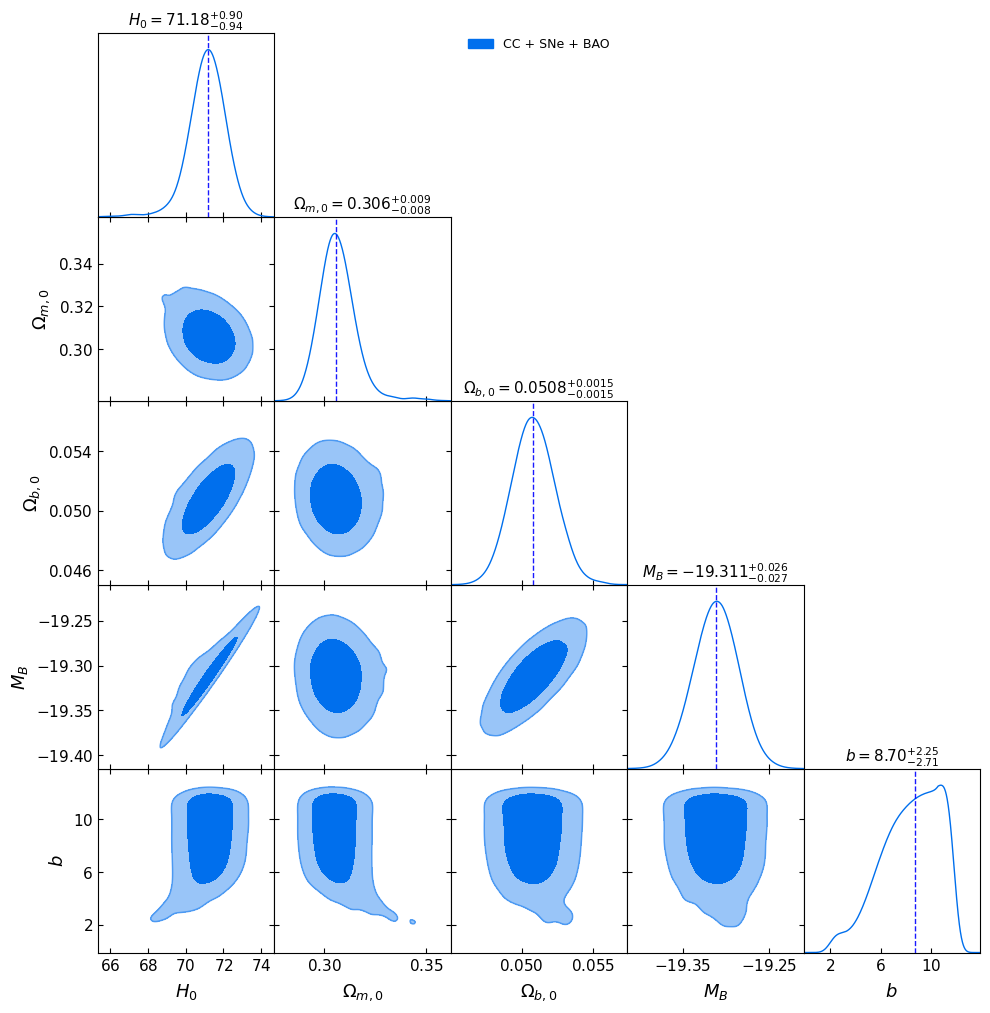

In [12]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "MB", "b"]
param_labels = [r"H_0", r"\Omega_{m,0}", r"\Omega_{b,0}", r"M_B", r"b"]

samples_gd = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 2.0
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3
g.triangle_plot(samples_gd, filled=True,
                legend_labels=["CC + SNe + BAO"],
                title_limit=0)

# ---- Fill under curve and add titles from samples ----
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "b": ".2f"}
for i, name in enumerate(param_names):
    samples = flat_samples[:, i]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    ep68    = upper68 - median
    em68    = median  - lower68
    ax   = g.subplots[i, i]
    line = ax.get_lines()[0]
    line.set_linewidth(1.0)

    # Median line
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)

    # Add title from samples
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)
    
plt.subplots_adjust(top=0.95)
figname = "Corner_AB_cc_sne_bao_jeff.png" if USE_LOG_b_PRIOR else "Corner_AB_cc_sne_bao.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ====================================================
# Marginalized statistics
# ====================================================

param_names_indices = [("H0", 0), ("Om0", 1), ("Ob", 2), ("MB", 3), ("b", 4)]
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "b": ".2f"}

print("\n" + "="*60)
print(f"{'Final Inference Results (AB model | CC + SNe + BAO data)':^60}")
print("="*60)

for name, idx in param_names_indices:
    samples = flat_samples[:, idx]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    lower95 = np.percentile(samples, 2.5)
    upper95 = np.percentile(samples, 97.5)
    ep68    = upper68 - median
    em68    = median  - lower68
    ep95    = upper95 - median
    em95    = median  - lower95
    fmt     = fmt_map[name]

    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:{fmt}}  (95% CL)")
    
print("\n" + "="*60)


  Final Inference Results (AB model | CC + SNe + BAO data)  

  H0:
    71.18 +0.90 -0.94  (68% CL)
    71.18 +1.76 -2.20  (95% CL)

  Om0:
    0.306 +0.009 -0.008  (68% CL)
    0.306 +0.022 -0.015  (95% CL)

  Ob:
    0.0508 +0.0015 -0.0015  (68% CL)
    0.0508 +0.0031 -0.0029  (95% CL)

  MB:
    -19.311 +0.026 -0.027  (68% CL)
    -19.311 +0.051 -0.052  (95% CL)

  b:
    8.70 +2.25 -2.71  (68% CL)
    8.70 +3.14 -5.50  (95% CL)



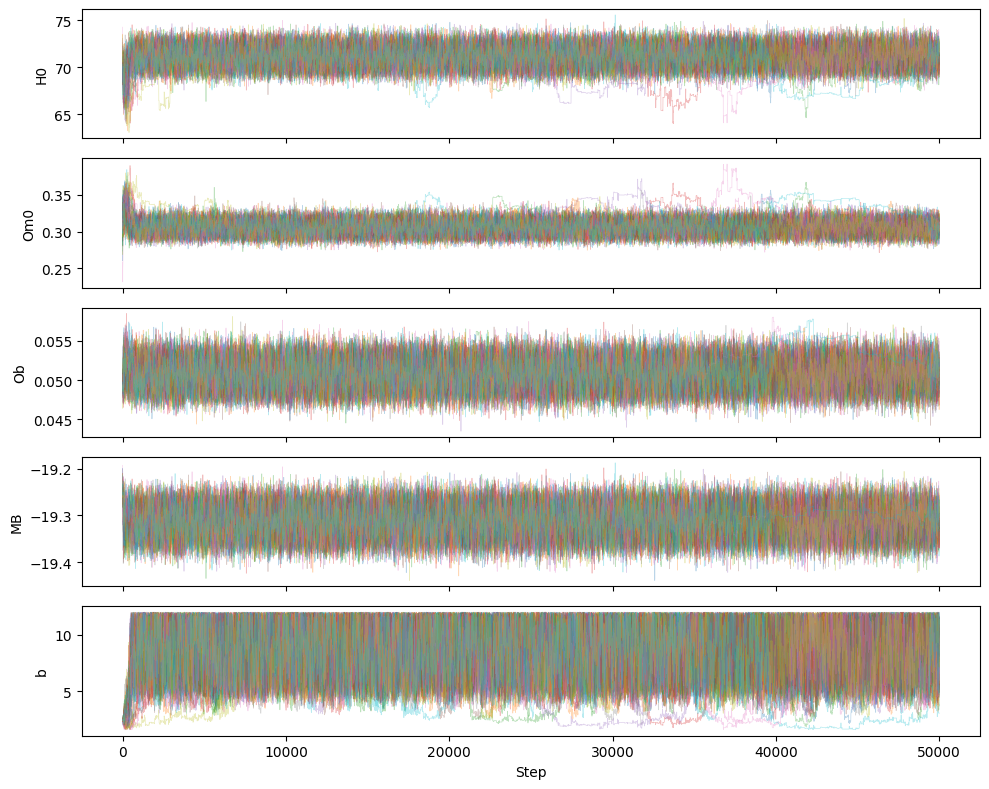

In [14]:
# ====================================================
# Walker chains
# ====================================================

chain_plot = sampler.get_chain().copy()
if USE_LOG_b_PRIOR:
    chain_plot[:, :, 4] = np.exp(chain_plot[:, :, 4])

fig, axes = plt.subplots(5, figsize=(10, 8), sharex=True)
for i, label in enumerate(["H0", "Om0", "Ob", "MB", "b"]):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
    
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()